# DR-Learner 实验结果解析

读取一次 `run_pipeline` 产出的目录（例如 `model_build/output/YYYYMMDD_HHMMSS`），汇总：

- **特征**：跨渠道 **特征筛选汇总表**（含 `n_protected`）+ 每渠道 **两阶段说明**、summary（`protected_resolved`）、带 `_kept_after_coarse` / `_kept_after_fine` 的 importance 表（头/尾展示）、`selected_features.txt` 最终名单（新流水线会落盘 CSV/summary）
- **模型**：倾向 / 结果 base 候选与选中；Lead leaderboard 与 `best_model_params`
- **ITE / Placebo（Test）** 与 **Total** 层指标与曲线图

**用法**：将下一格中的 `EXP_DIR` 改为你的实验目录**绝对路径**，然后 **Run All**。

**说明**：模型对比表默认用 pandas 行底色标出「选中」模型，这需要可选依赖 **`jinja2`**（`pip install jinja2`）。若未安装，表格会多一列 **`_is_best`**（`True` 即为该行被选中），功能不变。

In [1]:
from pathlib import Path

# 改为你的实验目录（绝对路径）
EXP_DIR = Path("/Users/jialuliang/Documents/WorkMagic/lift_test_calibration/feature_engineering/model_build/output/20260323_020322")

In [2]:
import json

import pandas as pd
from IPython.display import Image, Markdown, display


def _styler_ok() -> bool:
    try:
        import jinja2  # noqa: F401
    except ImportError:
        return False
    return True


def discover_channels(exp_dir: Path) -> list[str]:
    exp_dir = Path(exp_dir)
    out: list[str] = []
    for p in sorted(exp_dir.iterdir()):
        if p.is_dir() and (p / "ite_quality_test.json").exists():
            out.append(p.name)
    return out


def load_json(path: Path):
    path = Path(path)
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    return None


def style_kind_best(df: pd.DataFrame, kind_col: str, best: str | None):
    if df.empty or not best or kind_col not in df.columns:
        return df
    if not _styler_ok():
        out = df.copy()
        out["_is_best"] = out[kind_col] == best
        return out
    def _row(r):
        if r[kind_col] == best:
            return ["background-color: #d4edda"] * len(r)
        return [""] * len(r)
    return df.style.apply(_row, axis=1)


def style_family_best(df: pd.DataFrame, best_family: str | None):
    if df.empty or not best_family or "family" not in df.columns:
        return df
    if not _styler_ok():
        out = df.copy()
        out["_is_best"] = out["family"] == best_family
        return out
    def _row(r):
        if r["family"] == best_family:
            return ["background-color: #d4edda"] * len(r)
        return [""] * len(r)
    return df.style.apply(_row, axis=1)


channels = discover_channels(EXP_DIR)
print("EXP_DIR:", EXP_DIR.resolve())
print("Channels:", channels)
if not channels:
    print("No channel subdirs with ite_quality_test.json — check EXP_DIR.")

EXP_DIR: /Users/jialuliang/Documents/WorkMagic/lift_test_calibration/feature_engineering/model_build/output/20260323_020322
Channels: ['applovin', 'google', 'meta', 'microsoft', 'other', 'pinterest', 'snapchat', 'tiktok']


In [3]:
rows_fit: list[dict] = []
rows_ite: list[dict] = []
rows_lead: list[dict] = []
rows_fs: list[dict] = []

for ch in channels:
    base = load_json(EXP_DIR / ch / "base_model_scores.json")
    bp = load_json(EXP_DIR / ch / "best_model_params.json")
    iq = load_json(EXP_DIR / ch / "ite_quality_test.json")
    pb = load_json(EXP_DIR / ch / "placebo_report.json")
    sf = EXP_DIR / ch / "selected_features.txt"

    n_feat = 0
    if sf.exists():
        n_feat = sum(1 for line in sf.read_text(encoding="utf-8").splitlines() if line.strip())

    summ_path = EXP_DIR / ch / "feature_selection_summary.json"
    summ_fs = load_json(summ_path) if summ_path.exists() else None
    imp_vp = EXP_DIR / ch / "feature_importance_val.csv"
    imp_tp = EXP_DIR / ch / "feature_importance_train_on_coarse.csv"
    rows_fs.append(
        {
            "channel": ch,
            "has_summary": summ_fs is not None,
            "has_feat_imp_val": imp_vp.exists(),
            "has_feat_imp_train": imp_tp.exists(),
            "n_selected_txt_lines": n_feat,
            **(
                {
                    "n_candidates": summ_fs.get("n_candidates"),
                    "coarse_top_n": summ_fs.get("coarse_top_n"),
                    "fine_top_k": summ_fs.get("fine_top_k"),
                    "n_after_coarse": summ_fs.get("n_after_coarse"),
                    "n_selected_json": summ_fs.get("n_selected"),
                    "n_protected": summ_fs.get("n_protected"),
                    "method_val": summ_fs.get("effective_method_val"),
                    "method_train": summ_fs.get("effective_method_train"),
                }
                if summ_fs
                else {}
            ),
        }
    )

    rf: dict = {"channel": ch, "n_features": n_feat}
    if base:
        rf["best_propensity_kind"] = base.get("best_propensity_kind")
        rf["best_outcome_kind"] = base.get("best_outcome_kind")
        bk_p = base.get("best_propensity_kind")
        bk_o = base.get("best_outcome_kind")
        for ps in base.get("propensity_scores") or []:
            if ps.get("kind") == bk_p:
                rf["best_prop_log_loss"] = ps.get("log_loss")
                rf["best_prop_ece"] = ps.get("ece")
        for os in base.get("outcome_scores") or []:
            if os.get("kind") == bk_o:
                rf["best_outcome_mse"] = os.get("mse")
                rf["best_outcome_auc"] = os.get("auc")
    if bp:
        rf["lead_family"] = bp.get("family")
        rf["lead_val_mse"] = bp.get("val_mse")
    rows_fit.append(rf)

    if iq:
        ite = iq.get("ite_quality") or {}
        macro = ite.get("macro_ate") or {}
        dec = ite.get("micro_decile") or {}
        rows_ite.append(
            {
                "channel": ch,
                "pred_mean": macro.get("pred_mean"),
                "obs_ate": macro.get("obs_ate"),
                "ate_diff": macro.get("ate_diff"),
                "auuc_qini": ite.get("auuc_qini"),
                "decile_r": dec.get("decile_r"),
                "placebo_qini_observed": (pb or {}).get("qini_observed"),
                "placebo_qini_shuffled_mean": (pb or {}).get("qini_shuffled_mean"),
            }
        )

    lb = load_json(EXP_DIR / ch / "lead_leaderboard.json")
    if isinstance(lb, list):
        for e in lb:
            rows_lead.append(
                {"channel": ch, "family": e.get("family"), "val_mse": e.get("val_mse")}
            )

df_fit = pd.DataFrame(rows_fit)
df_ite = pd.DataFrame(rows_ite)
df_lead_long = pd.DataFrame(rows_lead)
df_fs = pd.DataFrame(rows_fs)

display(Markdown("## 跨渠道汇总"))
display(Markdown("### 特征筛选（跨渠道）"))
display(df_fs)
display(
    Markdown(
        "**列说明**：`has_summary` / `has_feat_imp_val` / `has_feat_imp_train` 表示是否落盘对应文件；"
        "`n_selected_txt_lines` 为 `selected_features.txt` 非空行数；`n_selected_json` 等与 summary 一致时可与 txt 核对。"
        " 若无 summary/csv，多为旧实验目录，需用当前版本 `run_pipeline` 重跑以生成完整 importance。"
    )
)
display(Markdown("### 拟合与选型（每渠道一行）"))
display(df_fit)
display(Markdown("### ITE 质量（Test）"))
display(df_ite)
display(Markdown("### Lead 全量对比（长表）"))
display(df_lead_long)

## 跨渠道汇总

### 特征筛选（跨渠道）

,channel,has_summary,has_feat_imp_val,has_feat_imp_train,n_selected_txt_lines
0,applovin,False,False,False,80
1,google,False,False,False,80
2,meta,False,False,False,80
3,microsoft,False,False,False,80
4,other,False,False,False,80
5,pinterest,False,False,False,80
6,snapchat,False,False,False,80
7,tiktok,False,False,False,80


**列说明**：`has_summary` / `has_feat_imp_val` / `has_feat_imp_train` 表示是否落盘对应文件；`n_selected_txt_lines` 为 `selected_features.txt` 非空行数；`n_selected_json` 等与 summary 一致时可与 txt 核对。 若无 summary/csv，多为旧实验目录，需用当前版本 `run_pipeline` 重跑以生成完整 importance。

### 拟合与选型（每渠道一行）

,channel,n_features,best_propensity_kind,best_outcome_kind,best_prop_log_loss,best_prop_ece,best_outcome_mse,best_outcome_auc,lead_family,lead_val_mse
0,applovin,80,lr,rf,0.228537,0.018063,0.118297,0.674237,rf,8.059964
1,google,80,xgb,rf,0.486844,0.009515,0.117861,0.691100,rf,2.713654
2,meta,80,lr,rf,0.641250,0.054150,0.118286,0.657995,lgbm,2.258129
3,microsoft,80,xgb,rf,0.030788,0.000056,0.118318,0.670644,lgbm,9.280607
4,other,80,xgb,rf,0.550529,0.006477,0.117555,0.698522,lgbm,0.927654
5,pinterest,80,lr,rf,0.001721,0.000127,0.118371,0.668848,rf,0.297595
6,snapchat,80,lr,lgbm,0.149880,0.017410,0.118273,0.673731,rf,18.789907
7,tiktok,80,xgb,rf,0.001874,0.000195,0.118503,0.668183,lgbm,0.414269


### ITE 质量（Test）

,channel,pred_mean,obs_ate,ate_diff,auuc_qini,decile_r,placebo_qini_observed,placebo_qini_shuffled_mean
0,applovin,-0.051710,-0.065077,0.013367,0.064679,-0.037060,0.101851,-0.001877
1,google,0.090922,0.106519,-0.015597,-0.084047,0.898363,-0.088529,-0.000745
2,meta,0.008634,0.060258,-0.051624,-0.052792,-0.525030,-0.016206,-0.000061
3,microsoft,0.083517,0.016490,0.067027,-0.093895,0.754854,-0.069469,-0.002654
4,other,-0.008997,-0.076816,0.067819,0.019638,0.954771,-0.004233,0.001744
5,pinterest,-0.095045,-0.104555,0.009510,0.171680,-0.084128,0.191402,0.004835
6,snapchat,-0.066620,-0.024688,-0.041933,-0.050437,-0.417476,-0.027236,-0.000817
7,tiktok,-0.081861,-0.101970,0.020109,0.025244,-0.113719,0.074417,0.000749


### Lead 全量对比（长表）

,channel,family,val_mse
0,applovin,lgbm,8.061055
1,applovin,xgb,8.069061
2,applovin,rf,8.059964
3,google,lgbm,2.716603
4,google,xgb,2.732623
5,google,rf,2.713654
6,meta,lgbm,2.258129
7,meta,xgb,2.272055
8,meta,rf,2.266725
9,microsoft,lgbm,9.280607


In [4]:
for ch in channels:
    display(Markdown(f"---\n## 渠道 `{ch}`"))

    display(Markdown("### 特征筛选（两阶段 FilterSelect）"))
    display(
        Markdown(
            "1. **Val 粗筛**：全体数值候选在验证集上算 importance，按 `rank` 排序；**`feature_selection_summary.json` 若含 `n_protected`**，则先强制保留 MODELING_DATA_SPEC §4.1 写死列（见 `protected_resolved`），再用剩余名额按 rank 填充至约 `coarse_top_n`（写死列过多时 `n_after_coarse` 可大于 `coarse_top_n`）。\n"
            "2. **Train 细筛**：在粗筛子集上于训练集再算 importance，同样先保留写死列再填满 `fine_top_k` 名额。\n"
            "下列 CSV 行顺序仍为 FilterSelect 的 rank 顺序；`_kept_after_coarse` / `_kept_after_fine` 仅表示「按纯前 N 行截断」的示意，与写死列并存时以 `selected_features.txt` 与 summary 为准。"
        )
    )

    summ_path = EXP_DIR / ch / "feature_selection_summary.json"
    imp_v = EXP_DIR / ch / "feature_importance_val.csv"
    imp_t = EXP_DIR / ch / "feature_importance_train_on_coarse.csv"
    sf_path = EXP_DIR / ch / "selected_features.txt"
    summ = load_json(summ_path) if summ_path.exists() else None

    if summ:
        display(Markdown("**`feature_selection_summary.json`**（与落盘 CSV 同目录）"))
        display(pd.DataFrame([summ]))
    else:
        display(
            Markdown(
                "*未找到 `feature_selection_summary.json`（多为旧次实验）。跨渠道汇总表里可见 `has_*`；完整排序需用当前版本 `run_pipeline` 重跑。*"
            )
        )

    coarse_n = int(summ["coarse_top_n"]) if summ and summ.get("coarse_top_n") is not None else None
    fine_k = int(summ["fine_top_k"]) if summ and summ.get("fine_top_k") is not None else None

    if imp_v.exists():
        dfv = pd.read_csv(imp_v).reset_index(drop=True)
        if coarse_n is not None and coarse_n > 0:
            dfv = dfv.copy()
            dfv["_kept_after_coarse"] = dfv.index < coarse_n
        display(
            Markdown(
                f"**Val — `feature_importance_val.csv`**：共 **{len(dfv)}** 行。"
                + (
                    f" `_kept_after_coarse=True` 表示进入粗筛后子集（按文件顺序前 **{coarse_n}** 行）。"
                    if coarse_n
                    else "（无 summary 时未标注截断行。）"
                )
            )
        )
        display(dfv.head(80))
        if len(dfv) > 80:
            display(Markdown("*… 以下为最后 20 行 …*"))
            display(dfv.tail(20))
    else:
        display(Markdown("*无 `feature_importance_val.csv`*"))

    if imp_t.exists():
        dft = pd.read_csv(imp_t).reset_index(drop=True)
        if fine_k is not None and fine_k > 0:
            dft = dft.copy()
            dft["_kept_after_fine"] = dft.index < fine_k
        display(
            Markdown(
                f"**Train（粗筛子集上）— `feature_importance_train_on_coarse.csv`**：共 **{len(dft)}** 行。"
                + (
                    f" `_kept_after_fine=True` 表示最终入选（按文件顺序前 **{fine_k}** 行）。"
                    if fine_k
                    else "（无 summary 时未标注截断行。）"
                )
            )
        )
        display(dft.head(80))
        if len(dft) > 80:
            display(Markdown("*… 以下为最后 20 行 …*"))
            display(dft.tail(20))
    else:
        display(Markdown("*无 `feature_importance_train_on_coarse.csv`*"))

    if sf_path.exists():
        names = [ln.strip() for ln in sf_path.read_text(encoding="utf-8").splitlines() if ln.strip()]
        display(Markdown(f"**最终名单 `selected_features.txt`**：**{len(names)}** 个特征（序号为写入顺序）"))
        display(pd.DataFrame({"order": range(1, len(names) + 1), "feature": names}).head(150))
        if len(names) > 150:
            display(Markdown(f"*仅展示前 150 个；共 {len(names)} 个。*"))
        if (
            summ
            and summ.get("n_selected") is not None
            and int(summ["n_selected"]) != len(names)
        ):
            display(
                Markdown(
                    f"*警告：`feature_selection_summary.json` 中 `n_selected`={summ['n_selected']} 与 txt 行数 {len(names)} 不一致。*"
                )
            )
    else:
        display(Markdown("*无 `selected_features.txt`*"))

    display(Markdown("### 模型候选与 Lead（Val）"))
    base = load_json(EXP_DIR / ch / "base_model_scores.json")
    if base:
        dfp = pd.DataFrame(base.get("propensity_scores") or [])
        dfo = pd.DataFrame(base.get("outcome_scores") or [])
        display(Markdown("**倾向模型候选（Val）** — 绿色 = `best_propensity_kind`"))
        display(style_kind_best(dfp, "kind", base.get("best_propensity_kind")))
        display(Markdown("**结果模型候选（Val）** — 绿色 = `best_outcome_kind`"))
        display(style_kind_best(dfo, "kind", base.get("best_outcome_kind")))

    lb = load_json(EXP_DIR / ch / "lead_leaderboard.json")
    bp = load_json(EXP_DIR / ch / "best_model_params.json")
    if isinstance(lb, list) and lb:
        dflb = pd.DataFrame(
            [{"family": x.get("family"), "val_mse": x.get("val_mse")} for x in lb]
        )
        bf = bp.get("family") if bp else None
        display(Markdown("**Lead Optuna 比拼（Val MSE）** — 绿色 = 选中族"))
        display(style_family_best(dflb, bf))
    if bp:
        display(Markdown("**选中 Lead**（`best_model_params.json`）"))
        display(pd.DataFrame([bp]))

---
## 渠道 `applovin`

### 特征筛选（两阶段 FilterSelect）

1. **Val 粗筛**：全体数值候选在验证集上算 importance，按 `rank` 排序后取前 `coarse_top_n` 进入子集。
2. **Train 细筛**：仅在该子集上、在训练集上再算 importance，取前 `fine_top_k` 写入 `selected_features.txt`。
下列 CSV 行顺序与 pipeline 内 `head(coarse_top_n)` / `head(fine_top_k)` 一致；`_kept_*` 列标出是否进入该阶段截断后的集合。

*未找到 `feature_selection_summary.json`（多为旧次实验）。跨渠道汇总表里可见 `has_*`；完整排序需用当前版本 `run_pipeline` 重跑。*

*无 `feature_importance_val.csv`*

...

,kind,mse,auc
0,lgbm,0.118567,0.667737
1,rf,0.118503,0.668183


**Lead Optuna 比拼（Val MSE）** — 绿色 = 选中族

,family,val_mse
0,lgbm,0.414269
1,xgb,0.415209
2,rf,0.414903


**选中 Lead**（`best_model_params.json`）

,family,n_estimators,max_depth,learning_rate,num_leaves,val_mse
0,lgbm,83,6,0.020692,104,0.414269


---
## Total（实验根目录）

**ite_quality_total.json**

,conversion_qini,conversion_qini_detail,decile_r2_mean_ite_vs_mean_y,sample_corr_sq,n_bins
0,0.091871,"{'area_model': 0.2662047610664603, 'area_rando...",0.068694,0.004233,10


**placebo_report_total.json**

,note,conversion_qini_shuffled_mean,conversion_qini_shuffled_std,conversion_qini_observed
0,shuffle ITE_total scores,-0.001248,0.002359,0.091871


**conversion_by_rank_total.csv**（前 30 行）

,bin,n,mean_score,conversion_rate
0,0,32675,0.493481,0.277888
1,1,32674,0.020998,0.114433
2,2,32674,-0.035322,0.615413
3,3,32674,-0.235878,0.198629
4,4,32674,-0.236489,0.189723
5,5,32674,-0.236489,0.189815
6,6,32674,-0.236489,0.187580
7,7,32674,-0.236489,0.184673
8,8,32674,-0.236489,0.190855
9,9,32674,-0.272473,0.200894


**conversion_rank_curve_total.png**

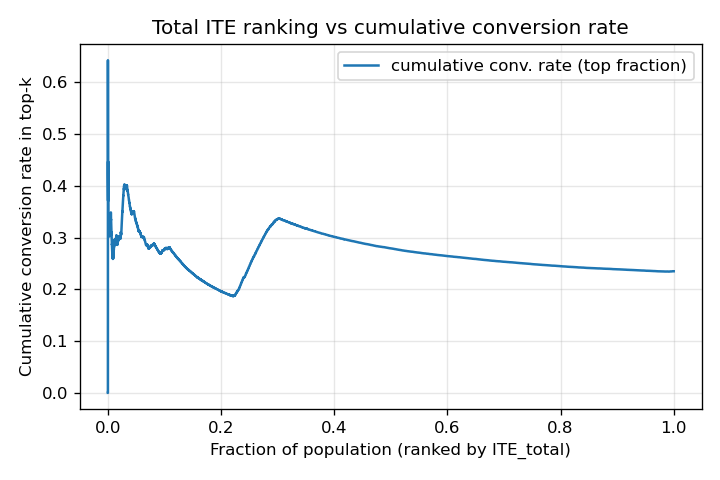

In [5]:
display(Markdown("---\n## Total（实验根目录）"))

iqt = load_json(EXP_DIR / "ite_quality_total.json")
if iqt:
    display(Markdown("**ite_quality_total.json**"))
    display(pd.DataFrame([iqt]))

pbt = load_json(EXP_DIR / "placebo_report_total.json")
if pbt:
    display(Markdown("**placebo_report_total.json**"))
    display(pd.DataFrame([pbt]))

conv = EXP_DIR / "conversion_by_rank_total.csv"
if conv.exists():
    display(Markdown("**conversion_by_rank_total.csv**（前 30 行）"))
    display(pd.read_csv(conv).head(30))

plot_p = EXP_DIR / "plots" / "conversion_rank_curve_total.png"
if plot_p.exists():
    display(Markdown("**conversion_rank_curve_total.png**"))
    display(Image(filename=str(plot_p)))
else:
    display(Markdown("*无 `plots/conversion_rank_curve_total.png`*"))